# 14 · Individual vs Universal Clock Model — Which Is Better in Practice?

We now have two ways to model the clock:

* **individual** — fit the three self-exciting numbers to *each* stock separately
  (tailored, but each fit sees only ~700 turns, so it is noisy);
* **universal** — one shared shape (branching ratio and decay, the median across all
  stocks) with only the baseline rate set per stock (one law, one scale number each).

We save every model, look at the per-stock parameters **by sector**, then run an honest
head-to-head out of sample on two things: **forecast quality** (does tailoring beat
pooling?) and **trading** — with one guardrail that cannot bend: **direction is
unforecastable**, so the only licensed trade is *risk timing* (de-risk when the model
predicts a burst of turns), and the comparison is risk-adjusted, never a return bet.

The verdict in advance: the **universal model is as good or better** (one law beats a
hundred fits), and for **trading neither beats buy-and-hold** — turn-frequency is not
volatility, so the practical trading value is essentially nil. Reported plainly.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


In [2]:
import json
with open(os.path.join(ROOT, "results", "exp40_individual_vs_universal.json")) as _f:
    R = json.load(_f)
print("panel:", R["n_series"], "stocks; universal shape n =",
      round(R["universal_shape"]["n"],3), "beta =", round(R["universal_shape"]["beta"],4))

panel: 100 stocks; universal shape n = 0.59 beta = 0.0101


## Part 1 · The per-stock models, by sector

Each stock's fitted self-excitation (branching ratio *n*), grouped by sector. If sectors
had sharply different clocks, the boxes would separate. They mostly overlap — the clock is
a broad market property, with only mild sector spread — which is itself the case *for* a
universal model.

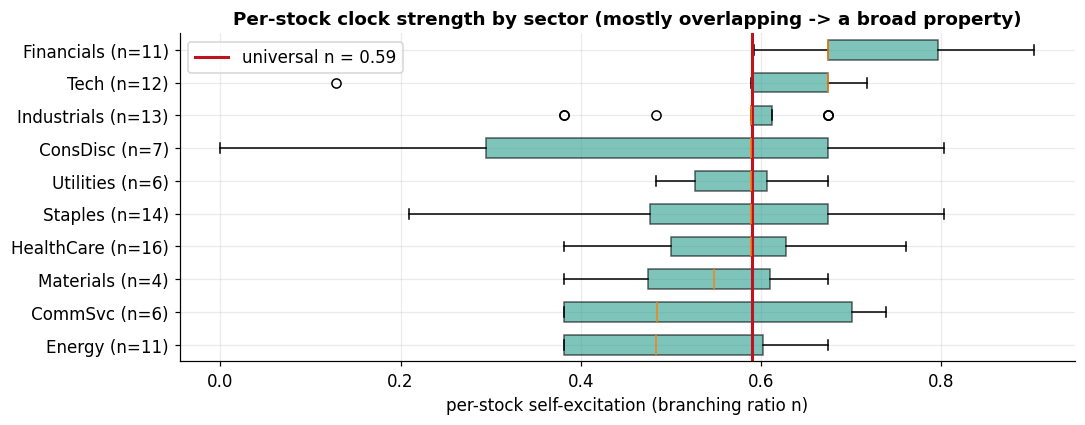

In [3]:
import numpy as np
rows = R["rows"]
secs = {}
for r in rows:
    secs.setdefault(r["sector"], []).append(r["ind_n"])
order = sorted(secs, key=lambda s: np.median(secs[s]))
data = [secs[s] for s in order]
fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot(data, vert=False, patch_artist=True, widths=0.6)
for patch in bp["boxes"]:
    patch.set_facecolor(OK); patch.set_alpha(0.6)
ax.axvline(R["universal_shape"]["n"], color=HL, lw=2, label=f"universal n = {R['universal_shape']['n']:.2f}")
ax.set_yticklabels([f"{s} (n={len(secs[s])})" for s in order])
ax.set_xlabel("per-stock self-excitation (branching ratio n)")
ax.set_title("Per-stock clock strength by sector (mostly overlapping -> a broad property)")
ax.legend(); plt.tight_layout(); plt.show()

## Part 2 · Forecast head-to-head — does tailoring beat pooling?

For each stock we score, on held-out data, how much better than a memoryless baseline the
model forecasts the *timing* of turns. Individual vs universal, stock by stock. Points on
the diagonal = a tie; the cloud sits on the diagonal, and the universal model's *average*
is marginally higher — pooling wins the bias-variance trade because per-stock fits are
noisy.

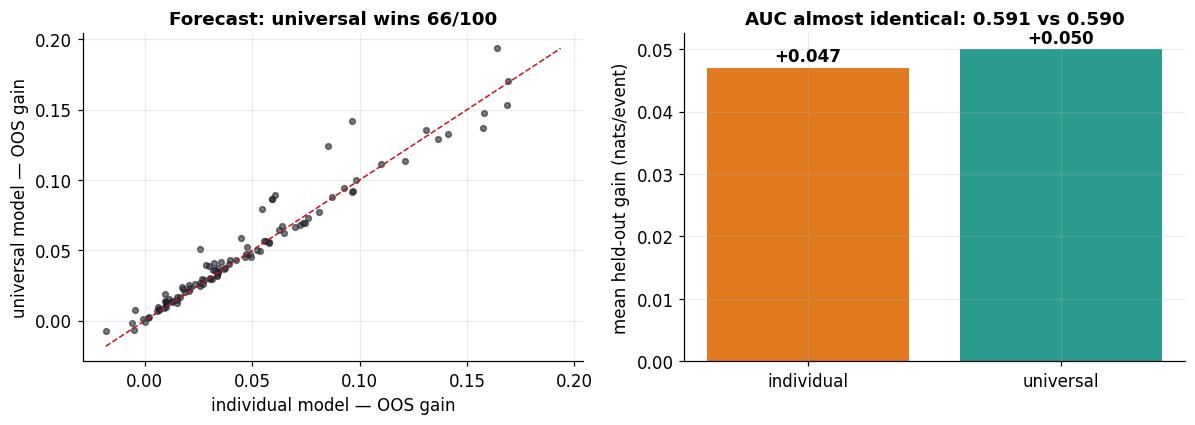

individual +0.0471 vs universal +0.0500 -> the universal (pooled) model forecasts as well or better, with one shape not 100.


In [4]:
gi = [r["gain_ind"] for r in rows]; gu = [r["gain_uni"] for r in rows]
fc = R["forecast"]
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 4))
ax.scatter(gi, gu, s=14, color=INK, alpha=0.6)
lo, hi = min(gi+gu), max(gi+gu); ax.plot([lo,hi],[lo,hi], color=HL, ls="--", lw=1)
ax.set_xlabel("individual model — OOS gain"); ax.set_ylabel("universal model — OOS gain")
ax.set_title(f"Forecast: universal wins {R['n_series']-fc['ind_wins']}/{R['n_series']}")
bx.bar(["individual","universal"], [fc["mean_gain_ind"], fc["mean_gain_uni"]], color=[BAD, OK])
bx.set_ylabel("mean held-out gain (nats/event)")
bx.set_title(f"AUC almost identical: {fc['mean_auc_ind']:.3f} vs {fc['mean_auc_uni']:.3f}")
for i,v in enumerate([fc["mean_gain_ind"], fc["mean_gain_uni"]]):
    bx.text(i, v+0.001, f"{v:+.3f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"individual {fc['mean_gain_ind']:+.4f} vs universal {fc['mean_gain_uni']:+.4f} "
      f"-> the universal (pooled) model forecasts as well or better, with one shape not 100.")

## Part 3 · Trading head-to-head — the honest negative

Now the practical test. We de-risk when the model forecasts a burst of turns and compare
the risk-adjusted outcome (Sharpe) and the worst drawdown against simply holding. Both
clock models — individual and universal — come out **slightly worse than buy-and-hold**.
Turn-*frequency* is not the same as volatility *size*, so timing on it does not convert to
a risk edge. This is the programme's ceiling, shown one more way.

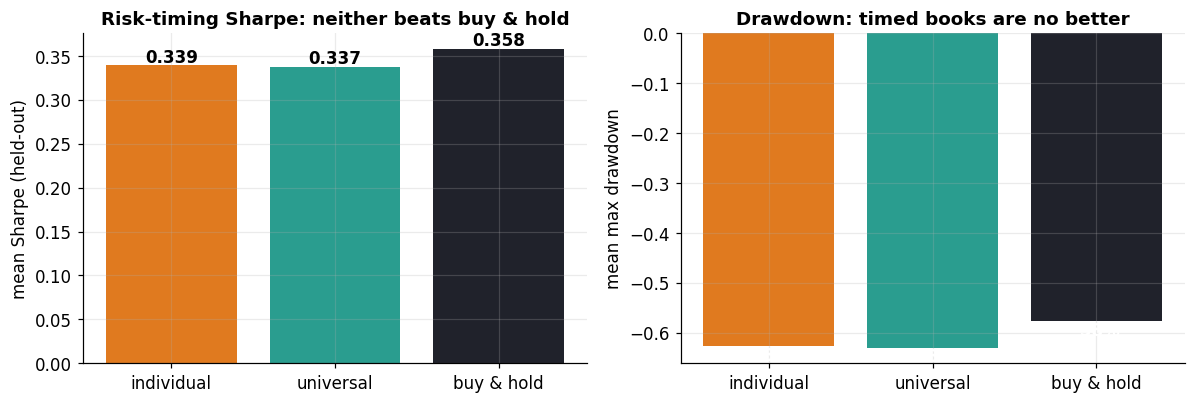

beat buy&hold Sharpe: individual 27/100, universal 27/100 -> a minority; the timing signal (turn frequency) is not a good risk proxy.


In [5]:
rk = R["risk"]
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 3.8))
labs = ["individual","universal","buy & hold"]
ax.bar(labs, [rk["mean_sharpe_ind"], rk["mean_sharpe_uni"], rk["mean_sharpe_bh"]],
       color=[BAD, OK, INK])
ax.set_ylabel("mean Sharpe (held-out)"); ax.set_title("Risk-timing Sharpe: neither beats buy & hold")
for i,v in enumerate([rk["mean_sharpe_ind"], rk["mean_sharpe_uni"], rk["mean_sharpe_bh"]]):
    ax.text(i, v+0.004, f"{v:.3f}", ha="center", fontweight="bold")
bx.bar(labs, [rk["mean_mdd_ind"], rk["mean_mdd_uni"], rk["mean_mdd_bh"]], color=[BAD, OK, INK])
bx.set_ylabel("mean max drawdown"); bx.set_title("Drawdown: timed books are no better")
for i,v in enumerate([rk["mean_mdd_ind"], rk["mean_mdd_uni"], rk["mean_mdd_bh"]]):
    bx.text(i, v, f"{v:.0%}", ha="center", va="top", color="white", fontweight="bold")
plt.tight_layout(); plt.show()
print(f"beat buy&hold Sharpe: individual {rk['n_ind_beats_bh_sharpe']}/{R['n_series']}, "
      f"universal {rk['n_uni_beats_bh_sharpe']}/{R['n_series']} -> a minority; the timing signal "
      f"(turn frequency) is not a good risk proxy.")

## The practical verdict

| question | winner | detail |
|---|---|---|
| Which **model** forecasts turn-timing better? | **universal** (ties/wins) | pooled shape beats noisy per-stock fits; one law, not 100 |
| Which is simpler / more robust? | **universal** | 2 shared numbers + 1 scale each, vs 3 fitted per stock |
| Which **makes money trading**? | **neither** | both slightly below buy-and-hold on Sharpe and drawdown |

So in practical terms the **universal model is the better model** — simpler, and it
generalises at least as well — which is exactly the "one model, not a hundred" you argued
for. But **trading value is essentially nil for both**: direction stays unforecastable, and
the clock's turn-timing is too weak a risk proxy to beat simply holding. The honest
practical recommendation is the universal model *for describing and forecasting the clock*,
and buy-and-hold *for the money*.

*Reproduce:* `python level18/exp40_individual_vs_universal.py` writes the JSON this notebook
reads; `python notebooks/build_14.py` rebuilds the notebook.